# `BasicMCMC` code

Follows the paper [[here](https://arxiv.org/abs/1903.11127)] and code [[here](https://github.com/ja-vazquez/Cosmologia_observacional)].

In [137]:
import numpy as np
import arviz as az

import corner
import matplotlib.pyplot as plt

import scipy.stats as st

Create points from straight line with errors

In [138]:
# For reproducibility, let's set the random number seed and generate the data:
np.random.seed(12)

# True parameter values
a_real = 3.
b_real = 2.
sigma = 0.3
   
# Size of dataset
N_points = 10

# Generating our data
def straight_line(a, b, sigma, size):
    x = np.sort(np.random.uniform(-8, 8, size))
    y = a+b*x+np.random.normal(loc=0.0, scale=sigma, size=size)
    return x, y

x1, y1 = straight_line(a_real, b_real, sigma, N_points)

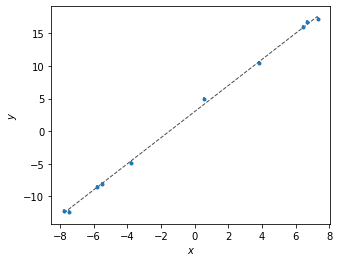

In [139]:
fig = plt.figure(figsize=(5, 4))
ax1 = fig.add_subplot(1, 1, 1)

ax1.errorbar(x1, y1, yerr=sigma, fmt='o', markersize=3)
ax1.plot(x1, a_real+b_real*x1, ls='--', c='black', lw=1, alpha=0.7)

ax1.set_xlabel(r'$x$')
ax1.set_ylabel(r'$y$')

plt.show()

In [140]:
def line_priors(alpha, beta, a_min=0, a_max=5, b_min=0, b_max=3):
    """
    Assumes uniform prior for (a, b), 
    intercept and slope of the line.
    """
    if (alpha<a_min)*(alpha>a_max)*(beta<b_min)*(beta>b_max):
        prior = 0
    else:
        prior = 1
        
    return prior


def line_lhd(alpha, beta, x_data, y_data, y_error):
    """
    Gaussian likelihood for data
    """
    
    y_sample = alpha+beta*x_data

    exponents = (y_data-y_sample)**2/(2*y_error**2)

    lhd = np.exp(-np.sum(exponents))

    return lhd

In [141]:
def Metropolis_mcmc_2D(alpha_new, beta_new, x_data, y_data, y_error=sigma, N_iterations=1e4, g_step=0.1):
    naccept = 0. #Accepted steps
    N_iterations = int(N_iterations)
    
    samples_alpha = np.zeros(N_iterations+1)
    samples_beta = np.zeros(N_iterations+1)
    samples_s = np.zeros(N_iterations+1)
        
    print(f"We are starting the MCMC run with {N_iterations} samples. \n")
    
    for i in range(N_iterations):        
        # Propose new samples, based on a Gaussian distribution
        # (this is similar to a 2D multivariate distribution).
        # We assume no correlation between a & b
        a_sample = np.random.normal(loc=alpha_new, scale=g_step, size=1)
        b_sample = np.random.normal(loc=beta_new, scale=g_step, size=1)
        
        # Calculate detailed balance probability
        # (because gaussians - above - are symmetric, we do not need to include them).
        
        p_before = line_lhd(alpha_new, beta_new, x_data, y_data, y_error)*line_priors(alpha_new, beta_new)
        p_sample = line_lhd(a_sample, b_sample, x_data, y_data, y_error)*line_priors(a_sample, b_sample)
        
        p_ratio = p_sample/p_before
        
        # Check if we have divergences and correct
        p_ratio = np.nan_to_num(p_ratio)
        rho = np.min([1, p_ratio])

        # Draw uniform
        u = np.random.uniform(0, 1, size=1)

        if u<rho:
            naccept += 1
            alpha_new, beta_new = a_sample, b_sample
        
        samples_alpha[i+1] = alpha_new
        samples_beta[i+1] = beta_new
        
    print(f"Efficiency = {naccept/N_iterations*100} %")
        
    return samples_alpha, samples_beta

In [142]:
S_alpha, S_beta = Metropolis_mcmc_2D(1, 1, x1, y1, y_error=1, N_iterations=8e3, g_step=0.1)

N_burn = 100
S_alpha_after_burn = S_alpha[N_burn:]
S_beta_after_burn = S_beta[N_burn:]

We are starting the MCMC run with 8000 samples. 

Efficiency = 49.075 %


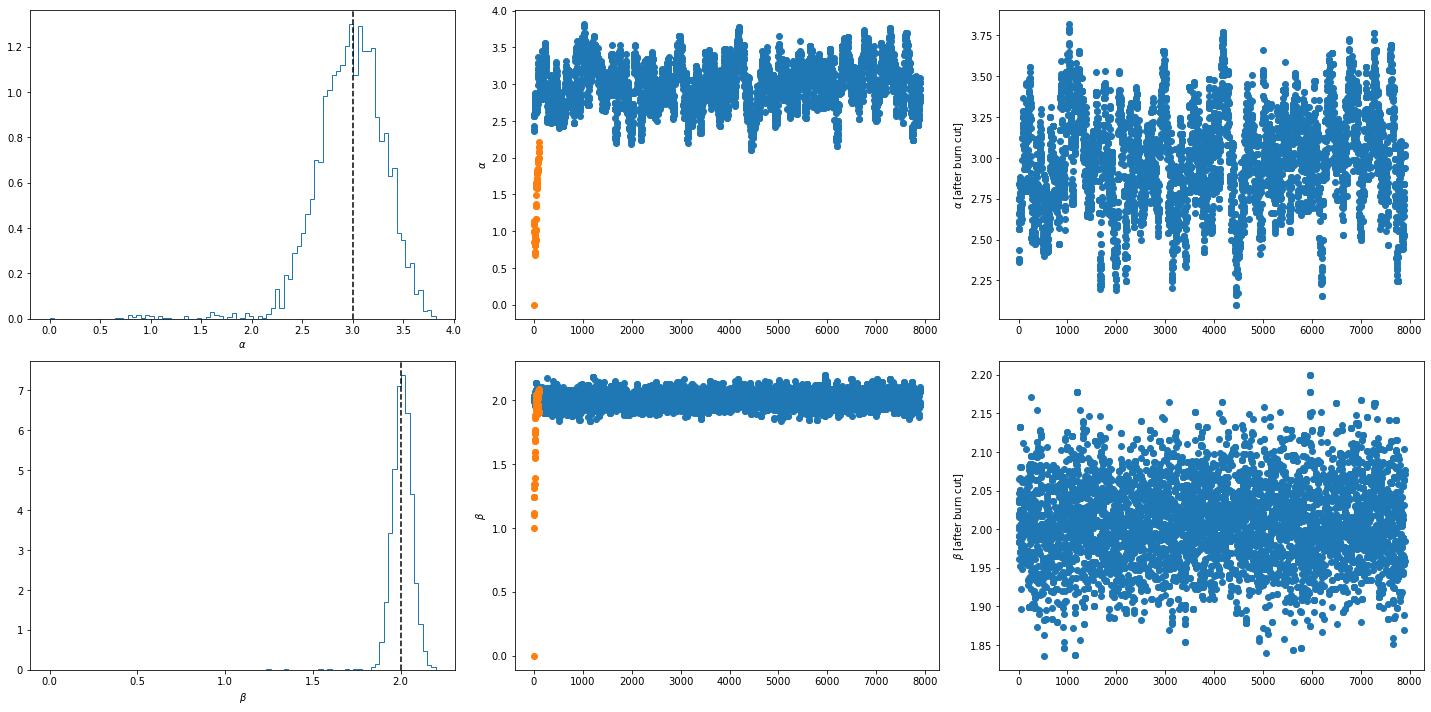

In [143]:
fig = plt.figure(figsize=(20, 10))
ax1 = fig.add_subplot(2, 3, 1)
ax2 = fig.add_subplot(2, 3, 2)
ax3 = fig.add_subplot(2, 3, 3)
ax4 = fig.add_subplot(2, 3, 4)
ax5 = fig.add_subplot(2, 3, 5)
ax6 = fig.add_subplot(2, 3, 6)

N_bins = int(np.sqrt(len(S_alpha)))
             
ax1.hist(S_alpha, bins=N_bins, density=True, histtype='step')
ax1.axvline(x=a_real, ls='--', c='black')
ax1.set_xlabel(r'$\alpha$')

ax2.scatter(np.arange(0, len(S_alpha_after_burn)), S_alpha_after_burn)
ax2.scatter(np.arange(0, len(S_alpha[:N_burn])), S_alpha[:N_burn])
ax2.set_ylabel(r'$\alpha$')

ax3.scatter(np.arange(0, len(S_alpha_after_burn)), S_alpha_after_burn)
ax3.set_ylabel(r'$\alpha$ [after burn cut]')


ax4.hist(S_beta, bins=N_bins, density=True, histtype='step')
ax4.axvline(x=b_real, ls='--', c='black')
ax4.set_xlabel(r'$\beta$')

ax5.scatter(np.arange(0, len(S_beta_after_burn)), S_beta_after_burn)
ax5.scatter(np.arange(0, len(S_beta[:N_burn])), S_beta[:N_burn])
ax5.set_ylabel(r'$\beta$')

ax6.scatter(np.arange(0, len(S_beta_after_burn)), S_beta_after_burn)
ax6.set_ylabel(r'$\beta$ [after burn cut]')

plt.tight_layout()
plt.show()

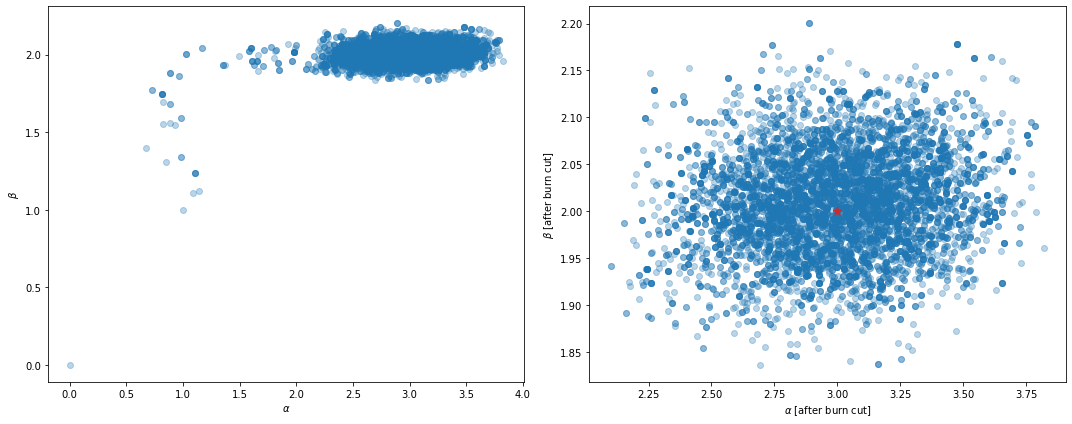

In [144]:
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.scatter(S_alpha, S_beta, alpha=0.3)
ax1.set_xlabel(r'$\alpha$')
ax1.set_ylabel(r'$\beta$')

ax2.scatter(S_alpha_after_burn, S_beta_after_burn, alpha=0.3)
ax2.scatter(a_real, b_real, alpha=1, c='tab:red', s=80, marker='*')
ax2.set_xlabel(r'$\alpha$ [after burn cut]')
ax2.set_ylabel(r'$\beta$ [after burn cut]')

plt.tight_layout()
plt.show()

In [145]:
ab_data = az.from_dict(
    posterior={"alpha": S_alpha_after_burn, "beta": S_beta_after_burn}
)

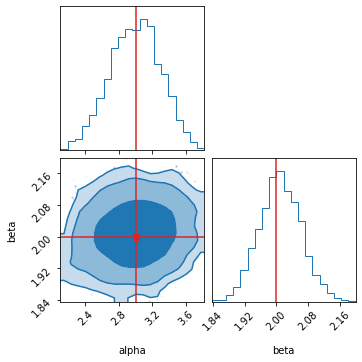

In [146]:
figure = corner.corner(ab_data, truths={"alpha": a_real, "beta": b_real}, smooth=True, fill_contours=True, color='tab:blue', truth_color='tab:red', levels=(0.68, 0.95, 0.99))

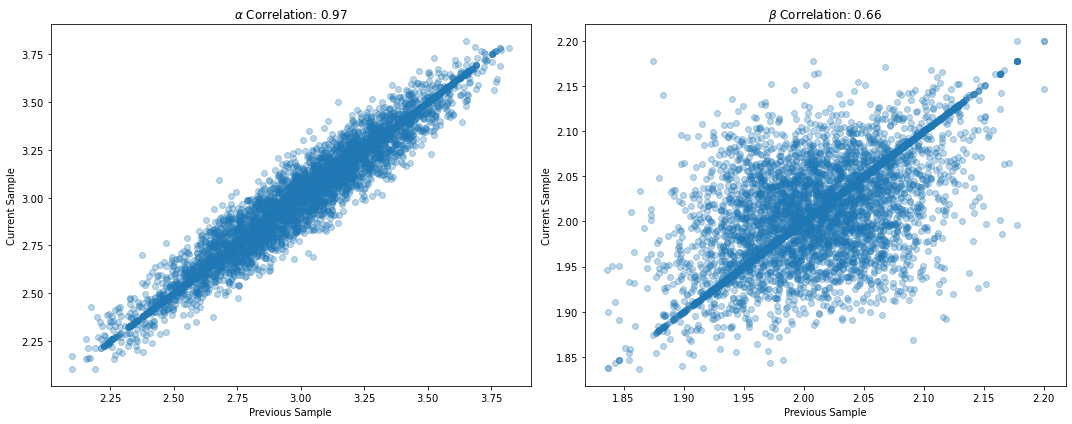

In [147]:
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.scatter(S_alpha_after_burn[:-1], S_alpha_after_burn[1:], alpha=0.3)
ax1.set_xlabel('Previous Sample')
ax1.set_ylabel('Current Sample')
ax1.set_title(fr'$\alpha$ Correlation: {round(st.pearsonr(S_alpha_after_burn[:-1], S_alpha_after_burn[1:])[0], 2)}')

ax2.scatter(S_beta_after_burn[:-1], S_beta_after_burn[1:], alpha=0.3)
ax2.set_xlabel('Previous Sample')
ax2.set_ylabel('Current Sample')
ax2.set_title(fr'$\beta$ Correlation: {round(st.pearsonr(S_beta_after_burn[:-1], S_beta_after_burn[1:])[0], 2)}')

plt.tight_layout()
plt.show()

--------------------------------------------------

## Repeat above with `Numpyro`

In [148]:
import jax
import jax.numpy as jnp

import numpyro
from numpyro import distributions as dist, infer

numpyro.set_host_device_count(2)

In [149]:
def linear_model(x, yerr, y=None):
    # These are the parameters that we're fitting and we're required to define explicit
    # priors using distributions from the numpyro.distributions module.
    alpha = numpyro.sample("alpha", dist.Uniform(0, 5))
    beta = numpyro.sample("beta", dist.Uniform(0, 3))

    # Then we specify the sampling distribution for the data, or the likelihood function.
    # Here we're using a numpyro.plate to indicate that the data are independent. This
    # isn't actually necessary here and we could have equivalently omitted the plate since
    # the Normal distribution can already handle vector-valued inputs. But, it's good to
    # get into the habit of using plates because some inference algorithms or distributions
    # can take advantage of knowing this structure.
    with numpyro.plate("data", len(x)):
        numpyro.sample("y", dist.Normal(beta * x + alpha, yerr), obs=y)

In [150]:
# Using the model above, we can now sample from the posterior distribution using the No
# U-Turn Sampler (NUTS).
sampler = infer.MCMC(
    infer.NUTS(linear_model),
    num_warmup=1000,
    num_samples=6000,
    num_chains=2,
    progress_bar=True,
)
%time sampler.run(jax.random.PRNGKey(0), x1, sigma, y=y1)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


  0%|          | 0/7000 [00:00<?, ?it/s]

  0%|          | 0/7000 [00:00<?, ?it/s]

CPU times: user 4.76 s, sys: 66.8 ms, total: 4.83 s
Wall time: 5.09 s


In [151]:
inf_data = az.from_numpyro(sampler)
az.summary(inf_data)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,3.033,0.095,2.855,3.213,0.001,0.001,9893.0,7658.0,1.0
beta,2.009,0.016,1.979,2.040,0.000,0.000,10396.0,7972.0,1.0


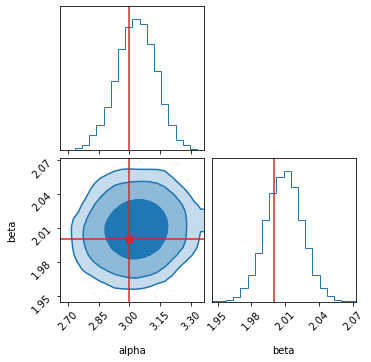

In [152]:
figure = corner.corner(inf_data, truths={"alpha": a_real, "beta": b_real}, smooth=True, fill_contours=True, color='tab:blue', truth_color='tab:red', levels=(0.68, 0.95, 0.99))

### Comparison plot

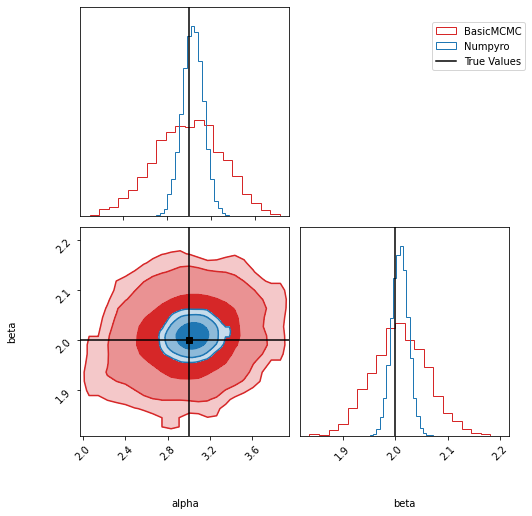

In [196]:
fig = plt.figure(figsize=(8,8))
corner.corner(ab_data, smooth=True, fill_contours=True, color='tab:red', levels=(0.68, 0.95, 0.99),\
              plot_datapoints=False, fig=fig)
corner.corner(inf_data, smooth=True, fill_contours=True, color='tab:blue', levels=(0.68, 0.95, 0.99),\
              truths={"alpha": a_real, "beta": b_real}, truth_color='black', plot_datapoints=False, fig=fig)

plt.legend(['BasicMCMC', 'Numpyro', 'True Values'], loc='upper right', bbox_to_anchor=(0.1, 1., 1, 1))
plt.show()